<a href="https://colab.research.google.com/github/elvoza/Curso-Introductorio-a-Python/blob/main/Soluci%C3%B3n%20Reto%20S10%20y%2011.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Felicidades, has terminado el Curso de Introducción a Python**

Para ello vamos a hacer un pequeño desafio que nos permita poner en practica todo lo que hemos aprendido a lo largo de este curso.

Empecemos creando nuestra base de datos usando Yahoo Finance

1. descarga 6 activos difrentes con los valores del ultimo año (entre ellos elige una criptomoneda y el dolar en pesos (COP=X), con una periodicidad díaria, y elije el valor del cierre (Close) y el volumen (Volume) de los movimientos, verifica los datos y limpia si es necesario con la estrategia de valores vecinos.

2. Crea una nueva variable categorica llamada "catvolume#NombreActivo", en función de uno de los activos y sus valores de volumen de venta, en donde dividas por cuartiles y le des los valores de "bajo" al primer cuartil. "medio" al segundo cuartil, "alto" al tercero y "muy_alto" al cuarto

3. Crea una columna adicional que se llame index y ponla en la primera columna de datos

4. Crea una columna de la criptomoneda en valores pesos multiplicandola por el valor del dolar en cada día.

5. Crea un resumen estadistico de las variables y analizar

6. Realice un analisis gráfico de las variables que incluya: (Series de tiempo, Histograma,  diagrama de cajas y bigotes y diagrama circular (Variable categorica)

7. Realice una matriz de correlación para las variables originales

8. Ajuste una media movil para una de los activos como estrategia predictora y calcule las estadisticas del error

9. Realice una matriz de gráficos donde se visualicen los diagramas de dispersión entre los valores "Close" de las Variables

10. Realice una regresión lineal de la criptomoneda en función de otro de los activos y calcule el ajuste del modelo.

In [167]:

#Importación y limpeza de datos
import yfinance as yf
tickers="CELSIA.CL", "NUTRESA.CL", "GRUPOARGOS.CL", "ISA.CL","BTC-USD", "COP=X"
data=yf.download(tickers=tickers,period="1y", interval="1d",
                 auto_adjust=True, prepost=True)[["Close", "Volume"]].fillna(method='bfill').dropna()

[*********************100%***********************]  6 of 6 completed
C:\Users\esney\AppData\Local\Temp\ipykernel_22124\4236262013.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  auto_adjust=True, prepost=True)[["Close", "Volume"]].fillna(method='bfill').dropna()


In [168]:
#Visualización de los datos
data.head()

Price               Close                                          \
Ticker            BTC-USD    CELSIA.CL        COP=X GRUPOARGOS.CL   
Date                                                                
2024-12-04   96593.570312  3333.324707  4425.750000  19158.130859   
2024-12-05   96593.570312  3347.590088  4425.750000  19293.593750   
2024-12-06   99920.710938  3347.590088  4413.669922  18964.613281   
2024-12-07   99923.335938  3338.079834  4376.152344  18867.857422   
2024-12-08  101236.015625  3338.079834  4376.152344  18867.857422   

Price                                      Volume                  \
Ticker            ISA.CL NUTRESA.CL       BTC-USD CELSIA.CL COP=X   
Date                                                                
2024-12-04  15844.304688    79000.0  1.492189e+11  466144.0   0.0   
2024-12-05  16183.825195    79000.0  1.492189e+11  156726.0   0.0   
2024-12-06  15919.753906    79000.0  9.453477e+10  111610.0   0.0   
2024-12-07  15863.166992    79000.0  4.417751e+10  160469.0   0.0   
2024-12-08  15863.166992    79000.0  4.412575e+10  160469.0   0.0   

Price                                          
Ticker     GRUPOARGOS.CL    ISA.CL NUTRESA.CL  
Date                                           
2024-12-04       56501.0  238521.0       21.0  
2024-12-05       99122.0  305117.0       34.0  
2024-12-06       85906.0  104920.0     1395.0  
2024-12-07      892647.0  271768.0       13.0  
2024-12-08      892647.0  271768.0       13.0

In [169]:
len(data)

366

In [171]:
data.isnull().sum()

Price   Ticker       
Close   BTC-USD          0
        CELSIA.CL        0
        COP=X            0
        GRUPOARGOS.CL    0
        ISA.CL           0
        NUTRESA.CL       0
Volume  BTC-USD          0
        CELSIA.CL        0
        COP=X            0
        GRUPOARGOS.CL    0
        ISA.CL           0
        NUTRESA.CL       0
dtype: int64

In [178]:
##2. Crea una nueva variable categorica llamada "catvolume#NombreActivo",
#en función de uno de los activos y sus valores de volumen de venta, en donde
#dividas por cuartiles y le des los valores de "bajo" al primer cuartil. "medio"
#al segundo cuartil, "alto" al tercero y "muy_alto" al cuarto

import pandas as pd
#Crear la nueva variable

volume_Nutresa = data['Volume']['GRUPOARGOS.CL']

# Calcular cuartiles y crear la columna
labels = ['bajo', 'medio', 'alto', 'muy_alto']
data['Volume', 'catvolumeGRUPOARGOS.CL'] = pd.qcut(volume_Nutresa, q=4, labels=labels, duplicates='drop')



In [179]:
#Validar nueva columna Catvolumexxxx
data

Price      Index          Close                                          \
Ticker                  BTC-USD    CELSIA.CL        COP=X GRUPOARGOS.CL   
Date                                                                      
2024-12-04     1   96593.570312  3333.324707  4425.750000  19158.130859   
2024-12-05     2   96593.570312  3347.590088  4425.750000  19293.593750   
2024-12-06     3   99920.710938  3347.590088  4413.669922  18964.613281   
2024-12-07     4   99923.335938  3338.079834  4376.152344  18867.857422   
2024-12-08     5  101236.015625  3338.079834  4376.152344  18867.857422   
...          ...            ...          ...          ...           ...   
2025-11-30   362   90394.312500  4900.000000  3691.856689  17420.000000   
2025-12-01   363   86321.570312  4900.000000  3691.856689  17420.000000   
2025-12-02   364   91350.203125  4905.000000  3808.399902  17420.000000   
2025-12-03   365   93527.804688  4865.000000  3816.250000  17900.000000   
2025-12-04   366   92425.210938  4950.000000  3768.149902  17360.000000   

Price                                      Volume                  \
Ticker            ISA.CL NUTRESA.CL       BTC-USD CELSIA.CL COP=X   
Date                                                                
2024-12-04  15844.304688    79000.0  1.492189e+11  466144.0   0.0   
2024-12-05  16183.825195    79000.0  1.492189e+11  156726.0   0.0   
2024-12-06  15919.753906    79000.0  9.453477e+10  111610.0   0.0   
2024-12-07  15863.166992    79000.0  4.417751e+10  160469.0   0.0   
2024-12-08  15863.166992    79000.0  4.412575e+10  160469.0   0.0   
...                  ...        ...           ...       ...   ...   
2025-11-30  25480.000000   262980.0  3.849790e+10  131675.0   0.0   
2025-12-01  25480.000000   262980.0  8.796289e+10  131675.0   0.0   
2025-12-02  25740.000000   262800.0  7.854680e+10  187359.0   0.0   
2025-12-03  25980.000000   272960.0  7.765020e+10   42165.0   0.0   
2025-12-04  25340.000000   256800.0  6.289874e+10  221392.0   0.0   

Price                                                          \
Ticker     GRUPOARGOS.CL    ISA.CL NUTRESA.CL catvolumeISA.CL   
Date                                                            
2024-12-04       56501.0  238521.0       21.0            alto   
2024-12-05       99122.0  305117.0       34.0            alto   
2024-12-06       85906.0  104920.0     1395.0            bajo   
2024-12-07      892647.0  271768.0       13.0            alto   
2024-12-08      892647.0  271768.0       13.0            alto   
...                  ...       ...        ...             ...   
2025-11-30       99308.0  220218.0     1905.0           medio   
2025-12-01       99308.0  220218.0     1905.0           medio   
2025-12-02      145484.0  326710.0      986.0            alto   
2025-12-03      162619.0  328226.0      557.0            alto   
2025-12-04      202092.0  806659.0      333.0        muy_alto   

Price                              
Ticker     catvolumeGRUPOARGOS.CL  
Date                               
2024-12-04                   bajo  
2024-12-05                  medio  
2024-12-06                  medio  
2024-12-07               muy_alto  
2024-12-08               muy_alto  
...                           ...  
2025-11-30                  medio  
2025-12-01                  medio  
2025-12-02                   alto  
2025-12-03                   alto  
2025-12-04                   alto  

[366 rows x 15 columns]

In [181]:
#Contar cantidad de valores por categoria
print(data['Volume', 'catvolumeGRUPOARGOS.CL'].value_counts())

(Volume, catvolumeGRUPOARGOS.CL)
medio       93
bajo        92
muy_alto    92
alto        89
Name: count, dtype: int64


In [182]:

## NUeva Columna llamada Index
Index = range(1, len(data) + 1)

print(Index)

data.insert(0, 'Index', Index)

range(1, 367)


ValueError: cannot insert Index, already exists

In [183]:
data

Price      Index          Close                                          \
Ticker                  BTC-USD    CELSIA.CL        COP=X GRUPOARGOS.CL   
Date                                                                      
2024-12-04     1   96593.570312  3333.324707  4425.750000  19158.130859   
2024-12-05     2   96593.570312  3347.590088  4425.750000  19293.593750   
2024-12-06     3   99920.710938  3347.590088  4413.669922  18964.613281   
2024-12-07     4   99923.335938  3338.079834  4376.152344  18867.857422   
2024-12-08     5  101236.015625  3338.079834  4376.152344  18867.857422   
...          ...            ...          ...          ...           ...   
2025-11-30   362   90394.312500  4900.000000  3691.856689  17420.000000   
2025-12-01   363   86321.570312  4900.000000  3691.856689  17420.000000   
2025-12-02   364   91350.203125  4905.000000  3808.399902  17420.000000   
2025-12-03   365   93527.804688  4865.000000  3816.250000  17900.000000   
2025-12-04   366   92425.210938  4950.000000  3768.149902  17360.000000   

Price                                      Volume                  \
Ticker            ISA.CL NUTRESA.CL       BTC-USD CELSIA.CL COP=X   
Date                                                                
2024-12-04  15844.304688    79000.0  1.492189e+11  466144.0   0.0   
2024-12-05  16183.825195    79000.0  1.492189e+11  156726.0   0.0   
2024-12-06  15919.753906    79000.0  9.453477e+10  111610.0   0.0   
2024-12-07  15863.166992    79000.0  4.417751e+10  160469.0   0.0   
2024-12-08  15863.166992    79000.0  4.412575e+10  160469.0   0.0   
...                  ...        ...           ...       ...   ...   
2025-11-30  25480.000000   262980.0  3.849790e+10  131675.0   0.0   
2025-12-01  25480.000000   262980.0  8.796289e+10  131675.0   0.0   
2025-12-02  25740.000000   262800.0  7.854680e+10  187359.0   0.0   
2025-12-03  25980.000000   272960.0  7.765020e+10   42165.0   0.0   
2025-12-04  25340.000000   256800.0  6.289874e+10  221392.0   0.0   

Price                                                          \
Ticker     GRUPOARGOS.CL    ISA.CL NUTRESA.CL catvolumeISA.CL   
Date                                                            
2024-12-04       56501.0  238521.0       21.0            alto   
2024-12-05       99122.0  305117.0       34.0            alto   
2024-12-06       85906.0  104920.0     1395.0            bajo   
2024-12-07      892647.0  271768.0       13.0            alto   
2024-12-08      892647.0  271768.0       13.0            alto   
...                  ...       ...        ...             ...   
2025-11-30       99308.0  220218.0     1905.0           medio   
2025-12-01       99308.0  220218.0     1905.0           medio   
2025-12-02      145484.0  326710.0      986.0            alto   
2025-12-03      162619.0  328226.0      557.0            alto   
2025-12-04      202092.0  806659.0      333.0        muy_alto   

Price                              
Ticker     catvolumeGRUPOARGOS.CL  
Date                               
2024-12-04                   bajo  
2024-12-05                  medio  
2024-12-06                  medio  
2024-12-07               muy_alto  
2024-12-08               muy_alto  
...                           ...  
2025-11-30                  medio  
2025-12-01                  medio  
2025-12-02                   alto  
2025-12-03                   alto  
2025-12-04                   alto  

[366 rows x 15 columns]

In [184]:
##Crea una columna de la criptomoneda en valores pesos multiplicandola por el
#valor del dolar en cada día.

BTCCOP = data['Close', 'BTC-USD'] * data['Close', 'COP=X']

data.insert(14,"BTC-COP",BTCCOP)

In [185]:
data

Price      Index          Close                                          \
Ticker                  BTC-USD    CELSIA.CL        COP=X GRUPOARGOS.CL   
Date                                                                      
2024-12-04     1   96593.570312  3333.324707  4425.750000  19158.130859   
2024-12-05     2   96593.570312  3347.590088  4425.750000  19293.593750   
2024-12-06     3   99920.710938  3347.590088  4413.669922  18964.613281   
2024-12-07     4   99923.335938  3338.079834  4376.152344  18867.857422   
2024-12-08     5  101236.015625  3338.079834  4376.152344  18867.857422   
...          ...            ...          ...          ...           ...   
2025-11-30   362   90394.312500  4900.000000  3691.856689  17420.000000   
2025-12-01   363   86321.570312  4900.000000  3691.856689  17420.000000   
2025-12-02   364   91350.203125  4905.000000  3808.399902  17420.000000   
2025-12-03   365   93527.804688  4865.000000  3816.250000  17900.000000   
2025-12-04   366   92425.210938  4950.000000  3768.149902  17360.000000   

Price                                      Volume                  \
Ticker            ISA.CL NUTRESA.CL       BTC-USD CELSIA.CL COP=X   
Date                                                                
2024-12-04  15844.304688    79000.0  1.492189e+11  466144.0   0.0   
2024-12-05  16183.825195    79000.0  1.492189e+11  156726.0   0.0   
2024-12-06  15919.753906    79000.0  9.453477e+10  111610.0   0.0   
2024-12-07  15863.166992    79000.0  4.417751e+10  160469.0   0.0   
2024-12-08  15863.166992    79000.0  4.412575e+10  160469.0   0.0   
...                  ...        ...           ...       ...   ...   
2025-11-30  25480.000000   262980.0  3.849790e+10  131675.0   0.0   
2025-12-01  25480.000000   262980.0  8.796289e+10  131675.0   0.0   
2025-12-02  25740.000000   262800.0  7.854680e+10  187359.0   0.0   
2025-12-03  25980.000000   272960.0  7.765020e+10   42165.0   0.0   
2025-12-04  25340.000000   256800.0  6.289874e+10  221392.0   0.0   

Price                                                               BTC-COP  \
Ticker     GRUPOARGOS.CL    ISA.CL NUTRESA.CL catvolumeISA.CL                 
Date                                                                          
2024-12-04       56501.0  238521.0       21.0            alto  4.274990e+08   
2024-12-05       99122.0  305117.0       34.0            alto  4.274990e+08   
2024-12-06       85906.0  104920.0     1395.0            bajo  4.410170e+08   
2024-12-07      892647.0  271768.0       13.0            alto  4.372797e+08   
2024-12-08      892647.0  271768.0       13.0            alto  4.430242e+08   
...                  ...       ...        ...             ...           ...   
2025-11-30       99308.0  220218.0     1905.0           medio  3.337228e+08   
2025-12-01       99308.0  220218.0     1905.0           medio  3.186869e+08   
2025-12-02      145484.0  326710.0      986.0            alto  3.478981e+08   
2025-12-03      162619.0  328226.0      557.0            alto  3.569255e+08   
2025-12-04      202092.0  806659.0      333.0        muy_alto  3.482720e+08   

Price                      Volume  
Ticker     catvolumeGRUPOARGOS.CL  
Date                               
2024-12-04                   bajo  
2024-12-05                  medio  
2024-12-06                  medio  
2024-12-07               muy_alto  
2024-12-08               muy_alto  
...                           ...  
2025-11-30                  medio  
2025-12-01                  medio  
2025-12-02                   alto  
2025-12-03                   alto  
2025-12-04                   alto  

[366 rows x 16 columns]

In [186]:
# 5. Crea un resumen estadistico de las variables y analizar

data.describe()

Price        Index          Close                                          \
Ticker                    BTC-USD    CELSIA.CL        COP=X GRUPOARGOS.CL   
count   366.000000     366.000000   366.000000   366.000000    366.000000   
mean    183.500000  102350.009691  4216.914455  4083.737555  19278.988786   
std     105.799338   11238.789908   529.204929   178.830172   1987.266378   
min       1.000000   76271.953125  3304.794189  3691.856689  14132.318359   
25%      92.250000   94529.041016  3631.501831  3984.860107  17600.000000   
50%     183.500000  103723.925781  4342.657959  4092.250488  19512.815430   
75%     274.750000  110977.412109  4730.496582  4204.062500  20918.609375   
max     366.000000  124752.531250  5000.000000  4425.750000  24558.734375   

Price                                      Volume                       \
Ticker        ISA.CL     NUTRESA.CL       BTC-USD     CELSIA.CL  COP=X   
count     366.000000     366.000000  3.660000e+02  3.660000e+02  366.0   
mean    20244.845724  142287.486339  5.498305e+10  2.639057e+05    0.0   
std      2747.278018   54242.846005  2.541820e+10  2.999626e+05    0.0   
min     15620.009766   71600.000000  9.863214e+09  0.000000e+00    0.0   
25%     18319.763672  118000.000000  3.734962e+10  1.144118e+05    0.0   
50%     19860.000000  126600.000000  5.155519e+10  1.678045e+05    0.0   
75%     22620.000000  149770.000000  6.938983e+10  3.058180e+05    0.0   
max     26300.000000  296000.000000  1.817464e+11  2.037922e+06    0.0   

Price                                                  BTC-COP  
Ticker GRUPOARGOS.CL        ISA.CL    NUTRESA.CL                
count   3.660000e+02  3.660000e+02    366.000000  3.660000e+02  
mean    2.428523e+05  3.161841e+05   2464.161202  4.173205e+08  
std     5.186723e+05  4.012950e+05   8615.158614  4.309885e+07  
min     0.000000e+00  0.000000e+00      0.000000  3.146875e+08  
25%     7.840125e+04  1.268740e+05    171.000000  3.950441e+08  
50%     1.358750e+05  2.314915e+05    493.000000  4.289036e+08  
75%     2.402458e+05  3.436030e+05   1579.000000  4.460572e+08  
max     5.138725e+06  3.251632e+06  71434.000000  4.956890e+08

In [187]:
## 6. Realice un analisis gráfico de las variables que incluya: (Series de tiempo, Histograma, diagrama de cajas y bigotes y diagrama circular (Variable categorica)
close_data = data['Close']
close_data.head()


Ticker,BTC-USD,CELSIA.CL,COP=X,GRUPOARGOS.CL,ISA.CL,NUTRESA.CL
Date,,,,,,
2024-12-04,96593.570312,3333.324707,4425.750000,19158.130859,15844.304688,79000.0
2024-12-05,96593.570312,3347.590088,4425.750000,19293.593750,16183.825195,79000.0
2024-12-06,99920.710938,3347.590088,4413.669922,18964.613281,15919.753906,79000.0
2024-12-07,99923.335938,3338.079834,4376.152344,18867.857422,15863.166992,79000.0
2024-12-08,101236.015625,3338.079834,4376.152344,18867.857422,15863.166992,79000.0


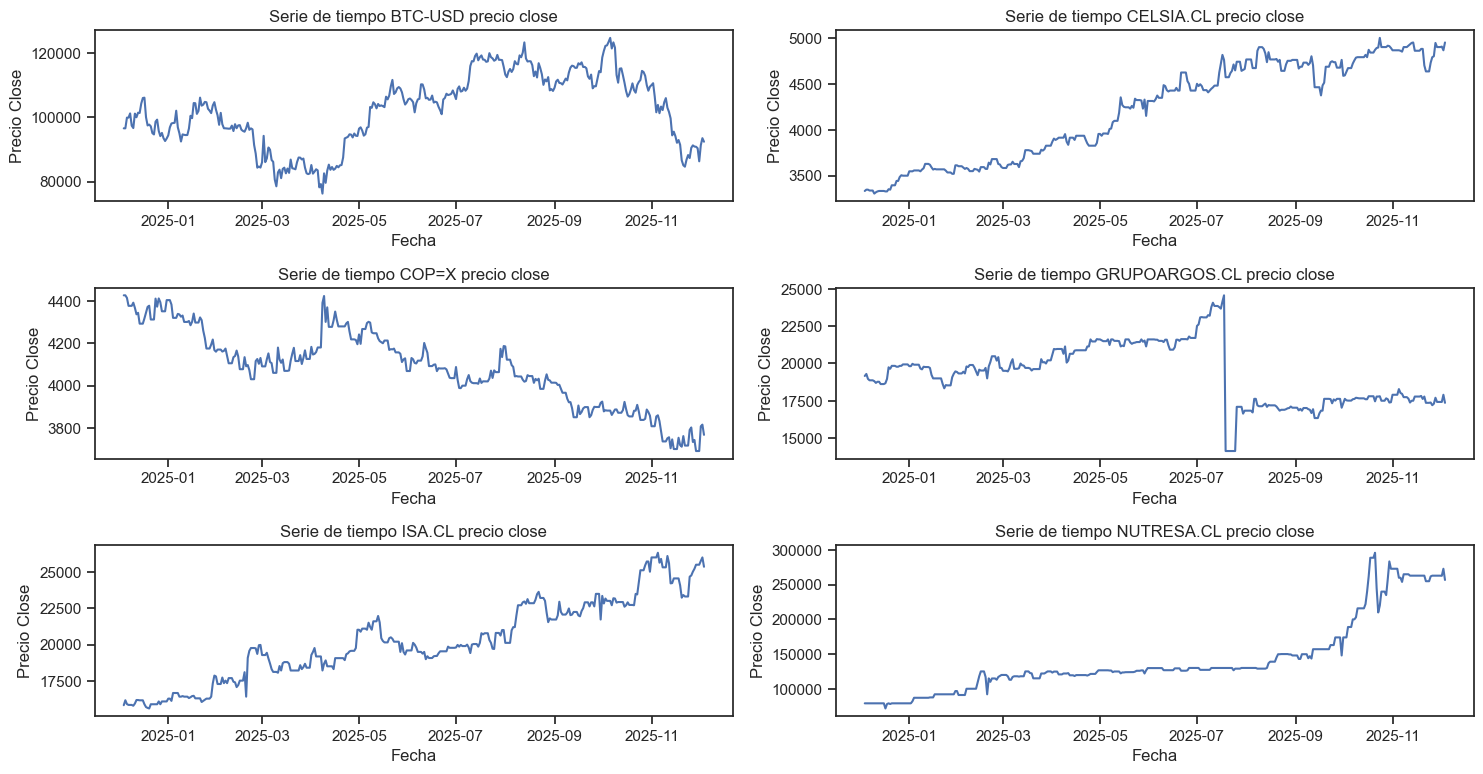

In [188]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))
for i, column in enumerate(close_data.columns):
    plt.subplot(len(close_data.columns) // 2 + 1, 2, i + 1)
    sns.lineplot(x=close_data.index, y=close_data[column])
    plt.title(f'Serie de tiempo {column} precio close')
    plt.xlabel('Fecha')
    plt.ylabel('Precio Close')
plt.tight_layout()
plt.show()

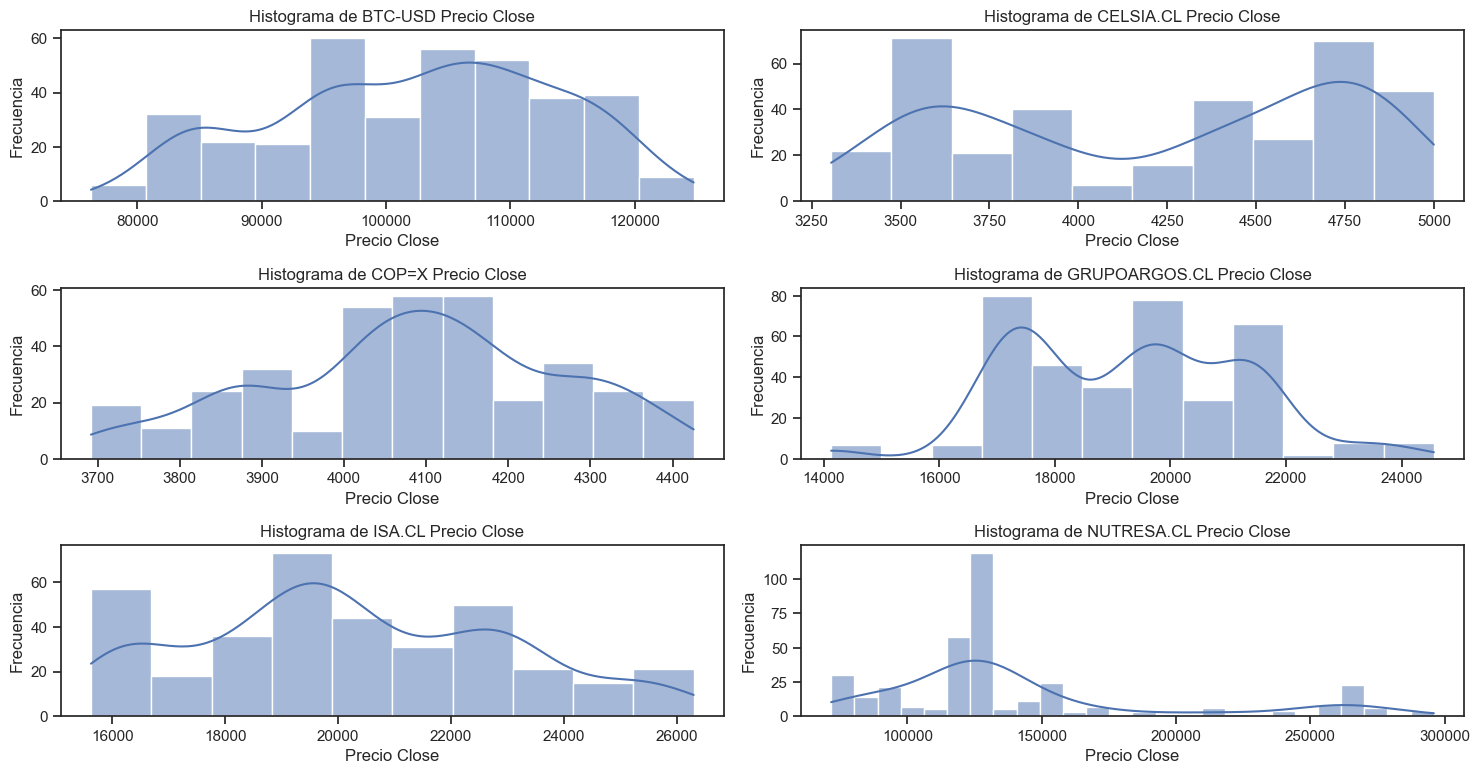

In [189]:
plt.figure(figsize=(15, 10))
for i, column in enumerate(close_data.columns):
    plt.subplot(len(close_data.columns) // 2 + 1, 2, i + 1)
    sns.histplot(close_data[column], kde=True)
    plt.title(f'Histograma de {column} Precio Close')
    plt.xlabel('Precio Close')
    plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

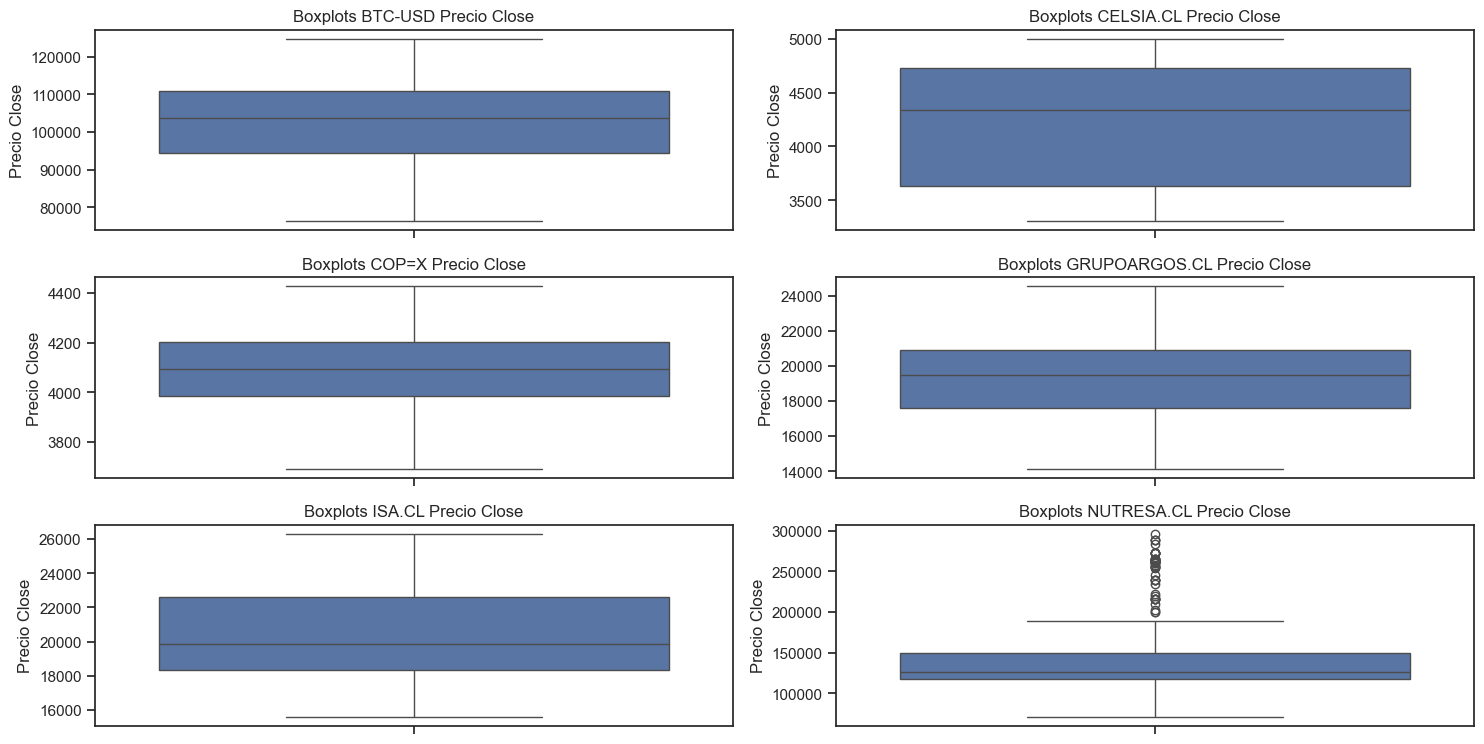

In [190]:
plt.figure(figsize=(15, 10))
for i, column in enumerate(close_data.columns):
    plt.subplot(len(close_data.columns) // 2 + 1, 2, i + 1)
    sns.boxplot(y=close_data[column])
    plt.title(f'Boxplots {column} Precio Close')
    plt.ylabel('Precio Close')
plt.tight_layout()
plt.show()

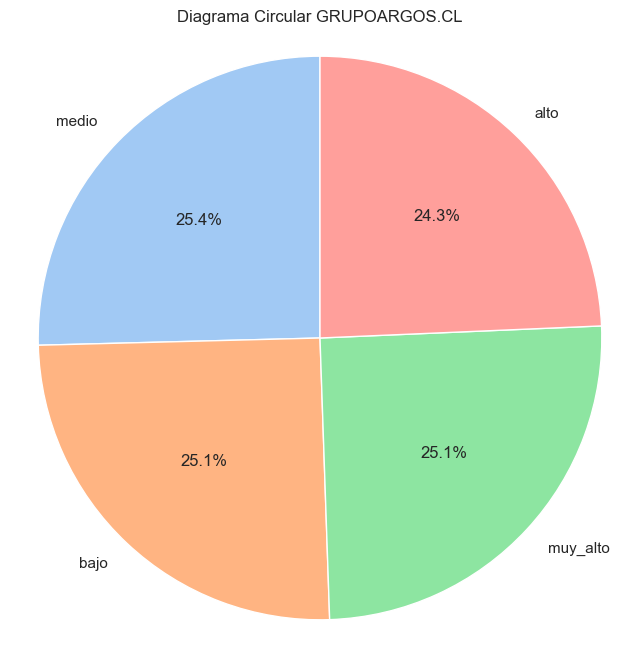

In [191]:
plt.figure(figsize=(8, 8))
volume_category_counts = data['Volume', 'catvolumeGRUPOARGOS.CL'].value_counts()
plt.pie(volume_category_counts, labels=volume_category_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Diagrama Circular GRUPOARGOS.CL')
plt.axis('equal')
plt.show()

In [192]:
## 7. Matriz de correllación de las variables

corr_k = data.corr(method="kendall", numeric_only=True)

corr_k

Price                     Index     Close                                    \
Ticker                            BTC-USD CELSIA.CL     COP=X GRUPOARGOS.CL   
Price   Ticker                                                                
Index                  1.000000  0.327811  0.856220 -0.726944     -0.132983   
Close   BTC-USD        0.327811  1.000000  0.353923 -0.285539     -0.263832   
        CELSIA.CL      0.856220  0.353923  1.000000 -0.627540     -0.139791   
        COP=X         -0.726944 -0.285539 -0.627540  1.000000      0.253897   
        GRUPOARGOS.CL -0.132983 -0.263832 -0.139791  0.253897      1.000000   
        ISA.CL         0.808364  0.312907  0.760821 -0.644055     -0.150624   
        NUTRESA.CL     0.888908  0.317358  0.793698 -0.725940     -0.148395   
Volume  BTC-USD        0.211874  0.244483  0.228388 -0.159799     -0.207004   
        CELSIA.CL     -0.107084 -0.171066 -0.128436  0.038335      0.084276   
        COP=X               NaN       NaN       NaN       NaN           NaN   
        GRUPOARGOS.CL  0.103534 -0.016197  0.067154 -0.180240     -0.106648   
        ISA.CL         0.068663 -0.054601  0.055389 -0.104156      0.011385   
        NUTRESA.CL    -0.012311 -0.230179 -0.027117 -0.026188      0.089421   
BTC-COP                0.117405  0.748271  0.173497 -0.033489     -0.158841   

Price                                         Volume                  \
Ticker                   ISA.CL NUTRESA.CL   BTC-USD CELSIA.CL COP=X   
Price   Ticker                                                         
Index                  0.808364   0.888908  0.211874 -0.107084   NaN   
Close   BTC-USD        0.312907   0.317358  0.244483 -0.171066   NaN   
        CELSIA.CL      0.760821   0.793698  0.228388 -0.128436   NaN   
        COP=X         -0.644055  -0.725940 -0.159799  0.038335   NaN   
        GRUPOARGOS.CL -0.150624  -0.148395 -0.207004  0.084276   NaN   
        ISA.CL         1.000000   0.792017  0.205821 -0.089238   NaN   
        NUTRESA.CL     0.792017   1.000000  0.194513 -0.099413   NaN   
Volume  BTC-USD        0.205821   0.194513  1.000000 -0.072911   NaN   
        CELSIA.CL     -0.089238  -0.099413 -0.072911  1.000000   NaN   
        COP=X               NaN        NaN       NaN       NaN   1.0   
        GRUPOARGOS.CL  0.116450   0.115398  0.031792  0.235944   NaN   
        ISA.CL         0.074754   0.081812  0.110732  0.279651   NaN   
        NUTRESA.CL     0.008691   0.001046 -0.057098  0.228084   NaN   
BTC-COP                0.125529   0.102371  0.234452 -0.168154   NaN   

Price                                                      BTC-COP  
Ticker                GRUPOARGOS.CL    ISA.CL NUTRESA.CL            
Price   Ticker                                                      
Index                      0.103534  0.068663  -0.012311  0.117405  
Close   BTC-USD           -0.016197 -0.054601  -0.230179  0.748271  
        CELSIA.CL          0.067154  0.055389  -0.027117  0.173497  
        COP=X             -0.180240 -0.104156  -0.026188 -0.033489  
        GRUPOARGOS.CL     -0.106648  0.011385   0.089421 -0.158841  
        ISA.CL             0.116450  0.074754   0.008691  0.125529  
        NUTRESA.CL         0.115398  0.081812   0.001046  0.102371  
Volume  BTC-USD            0.031792  0.110732  -0.057098  0.234452  
        CELSIA.CL          0.235944  0.279651   0.228084 -0.168154  
        COP=X                   NaN       NaN        NaN       NaN  
        GRUPOARGOS.CL      1.000000  0.331195   0.121955 -0.108538  
        ISA.CL             0.331195  1.000000   0.173840 -0.105719  
        NUTRESA.CL         0.121955  0.173840   1.000000 -0.267984  
BTC-COP                   -0.108538 -0.105719  -0.267984  1.000000

In [193]:
### 8. Ajuste una media movil para una de los activos como estrategia predictora y calcule las estadisticas del error

import numpy as np
from sklearn.metrics import r2_score, mean_squared_error

# Calcular media móvil de 5 periodos
# Asigna la nueva columna usando un MultiIndex para que se integre correctamente
data[('Price', "NUTRESA.CLMA5")] = data['Close']["NUTRESA.CL"].rolling(window=5).mean().shift(1).fillna(data['Close']["NUTRESA.CL"].iloc[0:4].mean())

# Preparar datos (eliminar NaN de la nueva columna para el cálculo de métricas)
# Usa el nombre de la columna MultiIndex para subset
datos_ma5 = data.dropna(subset=[('Price', "NUTRESA.CLMA5")])

# Las 'predicciones' son ahora los valores de la media móvil
y_pred_ma = datos_ma5[('Price', "NUTRESA.CLMA5")].values

# Alinear los valores originales de 'MINEROS.CL' con la longitud de los datos de la media móvil
y_original_aligned = datos_ma5['Close']['NUTRESA.CL'].values

# Parámetros y métricas
# En este enfoque de media móvil directa, no hay 'pendiente' ni 'intercepto' de un modelo de regresión
# Sin embargo, aún podemos calcular R2 y RMSE comparando la MA con los datos originales

r2 = r2_score(y_original_aligned, y_pred_ma)
rmse = np.sqrt(mean_squared_error(y_original_aligned, y_pred_ma))

print("="*50)
print("ESTRATEGIA PREDICTORIA: MEDIA MÓVIL (5 PERIODOS)")
print("="*50)
print(f"El pronóstico es directamente la Media Móvil de 5 períodos.")
print(f"\nMÉTRICAS DE RENDIMIENTO (vs. valores originales alineados):")
print(f"R²: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"Observaciones: {len(y_original_aligned)}")

ESTRATEGIA PREDICTORIA: MEDIA MÓVIL (5 PERIODOS)
El pronóstico es directamente la Media Móvil de 5 períodos.

MÉTRICAS DE RENDIMIENTO (vs. valores originales alineados):
R²: 0.9731
RMSE: 8878.9567
Observaciones: 366


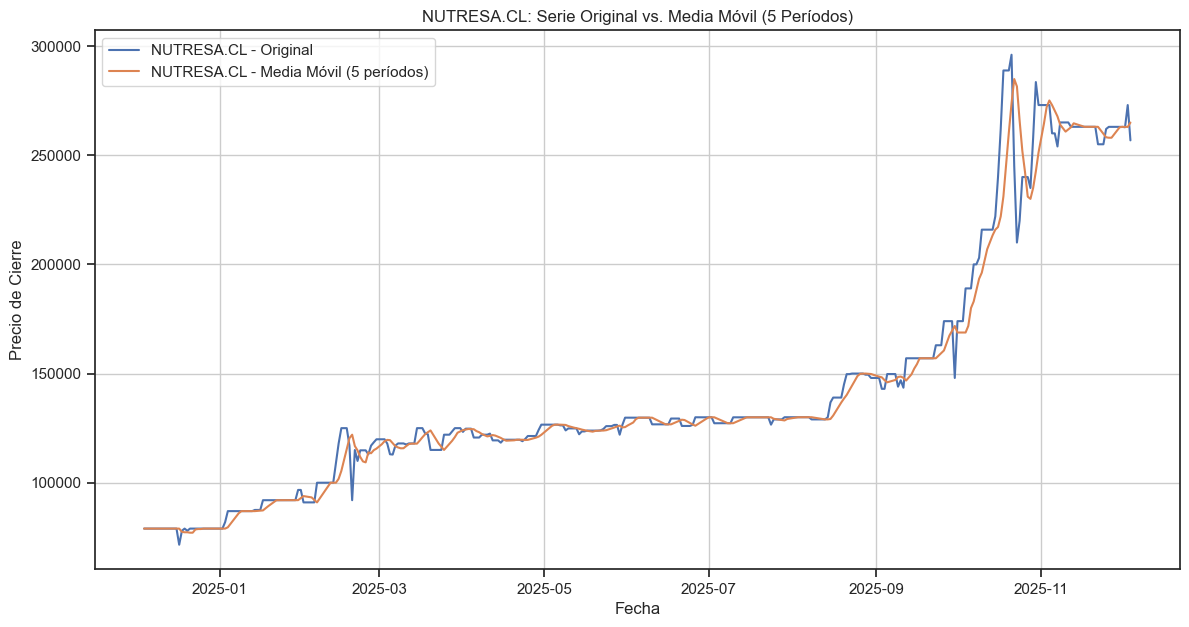

In [194]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))
sns.lineplot(x=datos_ma5.index, y=datos_ma5['Close']['NUTRESA.CL'], label='NUTRESA.CL - Original')
sns.lineplot(x=datos_ma5.index, y=datos_ma5[('Price', 'NUTRESA.CLMA5')], label='NUTRESA.CL - Media Móvil (5 períodos)')
plt.title('NUTRESA.CL: Serie Original vs. Media Móvil (5 Períodos)')
plt.xlabel('Fecha')
plt.ylabel('Precio de Cierre')
plt.legend()
plt.grid(True)
plt.show()

In [195]:
data

Price      Index          Close                                          \
Ticker                  BTC-USD    CELSIA.CL        COP=X GRUPOARGOS.CL   
Date                                                                      
2024-12-04     1   96593.570312  3333.324707  4425.750000  19158.130859   
2024-12-05     2   96593.570312  3347.590088  4425.750000  19293.593750   
2024-12-06     3   99920.710938  3347.590088  4413.669922  18964.613281   
2024-12-07     4   99923.335938  3338.079834  4376.152344  18867.857422   
2024-12-08     5  101236.015625  3338.079834  4376.152344  18867.857422   
...          ...            ...          ...          ...           ...   
2025-11-30   362   90394.312500  4900.000000  3691.856689  17420.000000   
2025-12-01   363   86321.570312  4900.000000  3691.856689  17420.000000   
2025-12-02   364   91350.203125  4905.000000  3808.399902  17420.000000   
2025-12-03   365   93527.804688  4865.000000  3816.250000  17900.000000   
2025-12-04   366   92425.210938  4950.000000  3768.149902  17360.000000   

Price                                      Volume                  \
Ticker            ISA.CL NUTRESA.CL       BTC-USD CELSIA.CL COP=X   
Date                                                                
2024-12-04  15844.304688    79000.0  1.492189e+11  466144.0   0.0   
2024-12-05  16183.825195    79000.0  1.492189e+11  156726.0   0.0   
2024-12-06  15919.753906    79000.0  9.453477e+10  111610.0   0.0   
2024-12-07  15863.166992    79000.0  4.417751e+10  160469.0   0.0   
2024-12-08  15863.166992    79000.0  4.412575e+10  160469.0   0.0   
...                  ...        ...           ...       ...   ...   
2025-11-30  25480.000000   262980.0  3.849790e+10  131675.0   0.0   
2025-12-01  25480.000000   262980.0  8.796289e+10  131675.0   0.0   
2025-12-02  25740.000000   262800.0  7.854680e+10  187359.0   0.0   
2025-12-03  25980.000000   272960.0  7.765020e+10   42165.0   0.0   
2025-12-04  25340.000000   256800.0  6.289874e+10  221392.0   0.0   

Price                                                               BTC-COP  \
Ticker     GRUPOARGOS.CL    ISA.CL NUTRESA.CL catvolumeISA.CL                 
Date                                                                          
2024-12-04       56501.0  238521.0       21.0            alto  4.274990e+08   
2024-12-05       99122.0  305117.0       34.0            alto  4.274990e+08   
2024-12-06       85906.0  104920.0     1395.0            bajo  4.410170e+08   
2024-12-07      892647.0  271768.0       13.0            alto  4.372797e+08   
2024-12-08      892647.0  271768.0       13.0            alto  4.430242e+08   
...                  ...       ...        ...             ...           ...   
2025-11-30       99308.0  220218.0     1905.0           medio  3.337228e+08   
2025-12-01       99308.0  220218.0     1905.0           medio  3.186869e+08   
2025-12-02      145484.0  326710.0      986.0            alto  3.478981e+08   
2025-12-03      162619.0  328226.0      557.0            alto  3.569255e+08   
2025-12-04      202092.0  806659.0      333.0        muy_alto  3.482720e+08   

Price                      Volume         Price  
Ticker     catvolumeGRUPOARGOS.CL NUTRESA.CLMA5  
Date                                             
2024-12-04                   bajo       79000.0  
2024-12-05                  medio       79000.0  
2024-12-06                  medio       79000.0  
2024-12-07               muy_alto       79000.0  
2024-12-08               muy_alto       79000.0  
...                           ...           ...  
2025-11-30                  medio      262784.0  
2025-12-01                  medio      262980.0  
2025-12-02                   alto      262980.0  
2025-12-03                   alto      262944.0  
2025-12-04                   alto      264940.0  

[366 rows x 17 columns]

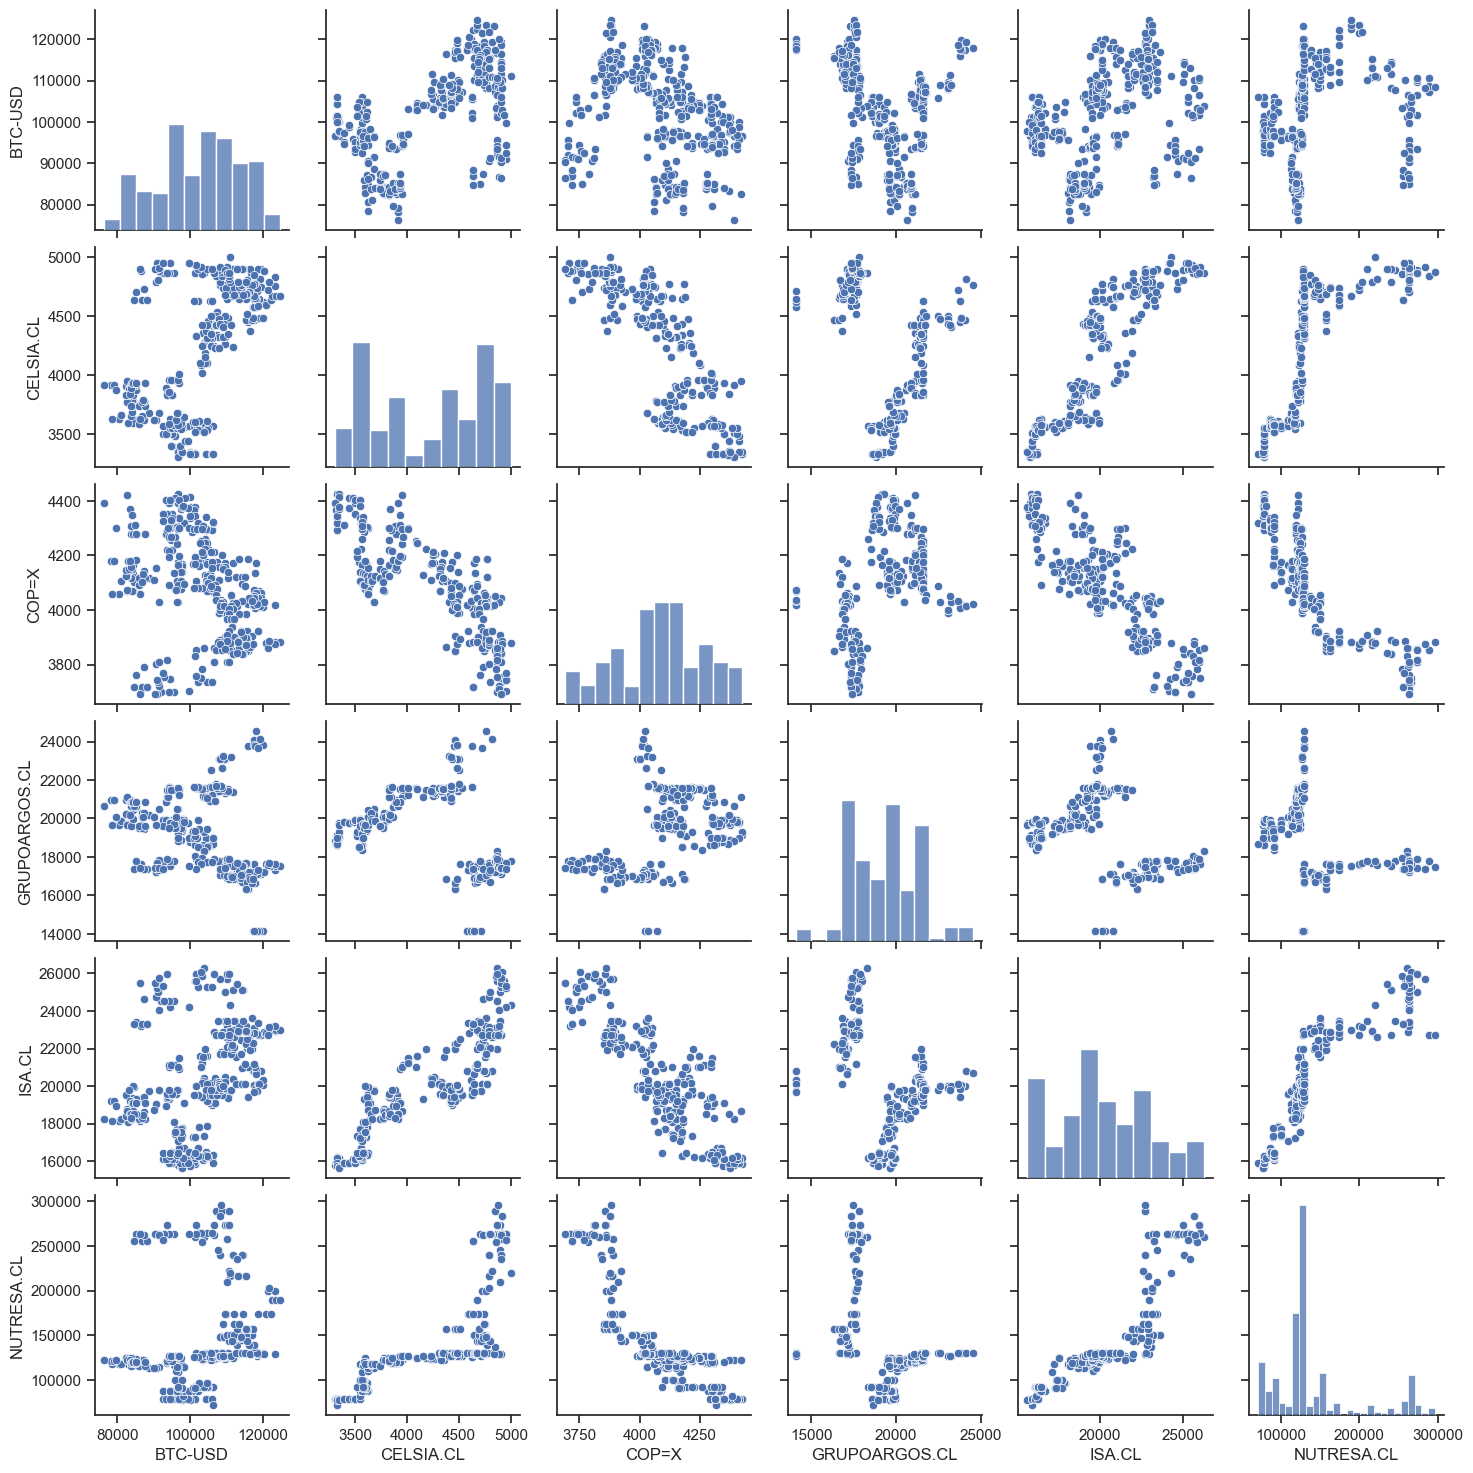

In [196]:
##9. Realice una matriz de gráficos donde se visualicen los diagramas de dispersión entre los valores "Close" de las Variables

import seaborn as sns
sns.set(style="ticks")

sns.pairplot(data["Close"])


In [197]:
###10. Realice una regresión lineal de la criptomoneda en función de otro de los activos y calcule el ajuste del modelo.

# Escogemos nuestra variable predictora como :
X=data["Close"]['ISA.CL'].values.reshape(-1,1)

# Escogemos nuestra variable objetivo  BTC-USD:
y=data["Close"]['BTC-USD'].values.reshape(-1,1)

In [198]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

#seleccionamos los datos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=3)

#entrenamos el modelo
linear  = LinearRegression()
linear.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [199]:
y_pred = linear.predict(X_test)

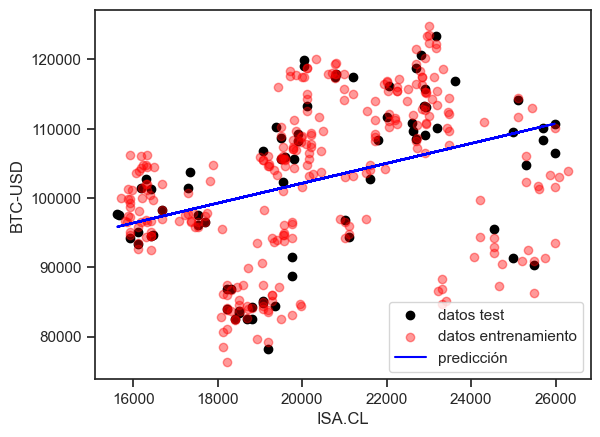

MAE:  8375.309869743518
MSE:  107078849.05190864
RMSE:  10347.891043681733
R2:  0.2059490699944726


In [200]:
plt.scatter(X_test, y_test,  color='black',label=r'datos test')
plt.scatter(X_train, y_train,  color='red',alpha=0.4,label=r'datos entrenamiento')
plt.plot(X_test, y_pred, color='blue',label=r'predicción')
plt.legend(loc='lower right')
plt.xlabel(r'ISA.CL')
plt.ylabel(r'BTC-USD')
plt.show()

print('MAE: ', metrics.mean_absolute_error(y_test, y_pred))
print('MSE: ', metrics.mean_squared_error(y_test, y_pred))
print('RMSE: ', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print('R2: ', metrics.r2_score(y_test, y_pred))